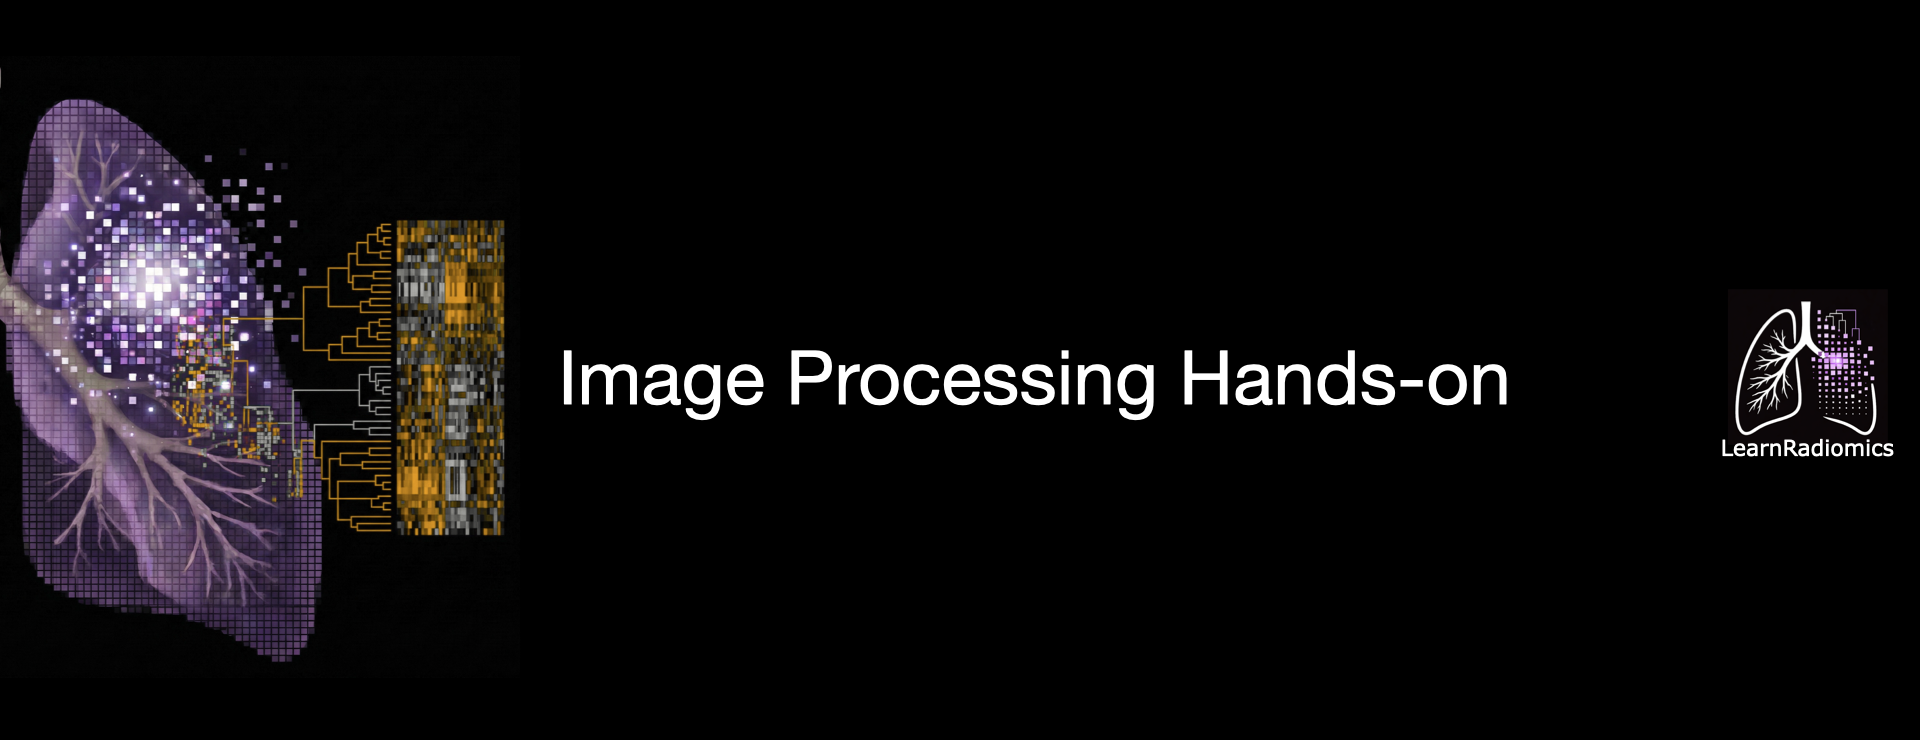

In [ ]:
## Load Libraries
import cv2
import os
import glob
import matplotlib.pyplot as plt
import requests
import json
import numpy as np

## Suppress warnings
import warnings
warnings.filterwarnings('ignore')

## Download the Kaggle token to access the dataset
json_response= requests.get("https://raw.github.com/learnradiomics/Image_processing/main/kaggle.json")

token = json.loads(json_response.text)
with open("kaggle.json", "w") as outfile:
    json.dump(token, outfile)

## Load data from Kaggle
! pip install kaggle
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

## Dataset
! kaggle datasets download hshenriquez/learnradiomics-imageprocessing
!unzip /content/learnradiomics-imageprocessing

### Search for directories


In [ ]:
## Current directory
print(os.getcwd())

#### Directory structure
* /content
* >> /natural_images
* >>>/birds
* >>>/mammals
* >>>>>/dogs
* >>>>>>/dogs/perro_1.jpg
* >>>>>/tigers
* >>>>>>/tigers/tigre_1.jpg

In [ ]:
PATH = "/content/Imagenes_naturales"

In [ ]:
## Check the files

os.listdir(PATH)

In [ ]:
path_birds = os.path.join(PATH, "aves")
path_mammals = os.path.join(PATH, "mamiferos")

In [ ]:
os.listdir(path_birds)

## Reading images

In [ ]:
file_path = os.path.join(path_birds,'ave_1.jpg' )
print(file_path)
image = cv2.imread(file_path)

In [ ]:
type(image)

In [ ]:
print("Dimensions:", image.shape)

## Image visualization

In [ ]:

plt.figure()
plt.imshow(image)
plt.show()

In [ ]:
## Color channels: RGB
## OpenCV loads: BGR

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure()
plt.imshow(image_rgb)
plt.title('Eagle image')
plt.show()

In [ ]:
## Access a pixel:

image_rgb[0,0,:]

In [ ]:
## Access specific coordinates

plt.figure()
plt.imshow(image_rgb[100:250,400:600,:])
plt.title('Eagle image')
plt.show()

In [ ]:
## Intensity values:

print("Minimum value:", image_rgb.min())
print("Maximum value:", image_rgb.max())
print("Mean value:", image_rgb.mean())

In [ ]:
## Compute histogram

hist_red = cv2.calcHist([image_rgb],[0],None,[256],[0,256])

plt.plot(hist_red)
plt.title('Red channel histogram')
plt.xlim([0,256])
plt.show()

In [ ]:
image_red = image_rgb[:,:,0]
image_green = image_rgb[:,:,1]
image_blue = image_rgb[:,:,2]


f = plt.figure(figsize=(15,15), frameon=False)

f.add_subplot(1, 3, 1)
plt.title("Red Channel")
plt.imshow(image_red, cmap = 'gray')

f.add_subplot(1, 3, 2)
plt.title("Green Channel")
plt.imshow(image_green, cmap = 'gray')

f.add_subplot(1, 3, 3)
plt.title("Blue Channel")
plt.imshow(image_blue, cmap = 'gray')

plt.show()


## Resize image:



In [ ]:
## Original size

print("Original size:", image_rgb.shape)

## Goal: convert the image to 512 x 512

target_size = (512,512)

resized_image = cv2.resize(image_rgb, target_size, interpolation=cv2.INTER_LINEAR)

print("New size:", resized_image.shape)


In [ ]:
plt.figure()
plt.imshow(resized_image)
plt.show()

### Processing multiple images

In [ ]:

image_files = (
    glob.glob('/content/Imagenes_naturales/**/*.jpg',recursive=True) +
    glob.glob('/content/Imagenes_naturales/**/*.jpeg',recursive=True) +
    glob.glob('/content/Imagenes_naturales/**/*.png',recursive=True) )

In [ ]:
target_size = (512,512)

image_list = []

for image_path in image_files:
  print(image_path)
  image = cv2.imread(image_path)
  image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  resized_image = cv2.resize(image_rgb, target_size, interpolation=cv2.INTER_LINEAR)
  image_list.append(resized_image)

In [ ]:
print(len(image_list))

In [ ]:
image_list[1]

In [ ]:

fig, axes1 = plt.subplots(3,4,figsize=(10,10))

i = 0
for j in range(3):
  for k in range(4):
    axes1[j][k].set_axis_off()
    axes1[j][k].imshow(image_list[i], cmap='gray')
    i += 1

plt.show()

In [ ]:
## Conversion to array:

images_array = np.array(image_list)
images_array.shape

In [ ]:
images_array.mean()